# Volume 2: The Discrete Fourier Transform
    <Lane Lindstrom>>
    <Math 321>
    <04/02/2026>

In [2]:
import IPython
import numpy as np
from scipy.io import wavfile
from scipy.fftpack import fft
from matplotlib import pyplot as plt

In [3]:
plt.rcParams["figure.dpi"] = 300             # Fix plot quality.
plt.rcParams["figure.figsize"] = (12, 3)      # Change plot size / aspect (you may adjust this).

In [4]:
class SoundWave(object):
    """A class for working with digital audio signals."""

    # Problem 1
    def __init__(self, rate, samples):
        """Set the SoundWave class attributes.

        Parameters:
            rate (int): The sample rate of the sound.
            samples ((n,) ndarray): NumPy array of samples.
        """
        self.rate = rate
        self.samples = samples

    # Problems 1 and 7
    def plot(self):
        """Plot the graph of the sound wave (time versus amplitude)."""
        t = np.arange(len(self.samples)) / self.rate
        plt.plot(t, self.samples, color='blue')
        plt.xlabel("Time (seconds)")
        plt.ylabel("Amplitude")

        plt.xlim(t[0], t[-1])
        plt.ylim(-32768, 32767)
        plt.grid(True)
        plt.title("Plotted Soundwave")
        plt.savefig("plottedfig.png")

    # Problem 2
    def export(self, filename, force=False):
        """Generate a wav file from the sample rate and samples. 
        If the array of samples is not of type np.int16, scale it before exporting.

        Parameters:
            filename (str): The name of the wav file to export the sound to.
        """
        scaled_samples = self.samples
        if (self.samples.dtype != np.int16) or force:
            scaled_samples = ((self.samples/max(self.samples)) * 32767).astype(np.int16)

        wavfile.write(filename, self.rate, scaled_samples)
    
    # Problem 4
    def __add__(self, other):
        """Combine the samples from two SoundWave objects.

        Parameters:
            other (SoundWave): An object containing the samples to add
                to the samples contained in this object.
        
        Returns:
            (SoundWave): A new SoundWave instance with the combined samples.

        Raises:
            ValueError: if the two sample arrays are not the same length.
        """
        if isinstance(other, SoundWave):
            if len(self.samples) != len(other.samples):
                raise ValueError
            return SoundWave(self.rate, self.samples + other.samples)

    # Problem 4
    def __rshift__(self, other):
        """Concatentate the samples from two SoundWave objects.

        Parameters:
            other (SoundWave): An object containing the samples to concatenate
                to the samples contained in this object.

        Raises:
            ValueError: if the two sample rates are not equal.
        """
        if isinstance(other, SoundWave):
            if self.rate != other.rate:
                raise ValueError
            return SoundWave(self.rate, np.concatenate((self.samples, other.samples)))



## Problem 1

- Implement `SoundWave.__init__()`.
- Implement `SoundWave.plot()`.
- Use SciPy's `wavfile.read()` and the `SoundWave` class to plot `tada.wav` in the cell below.

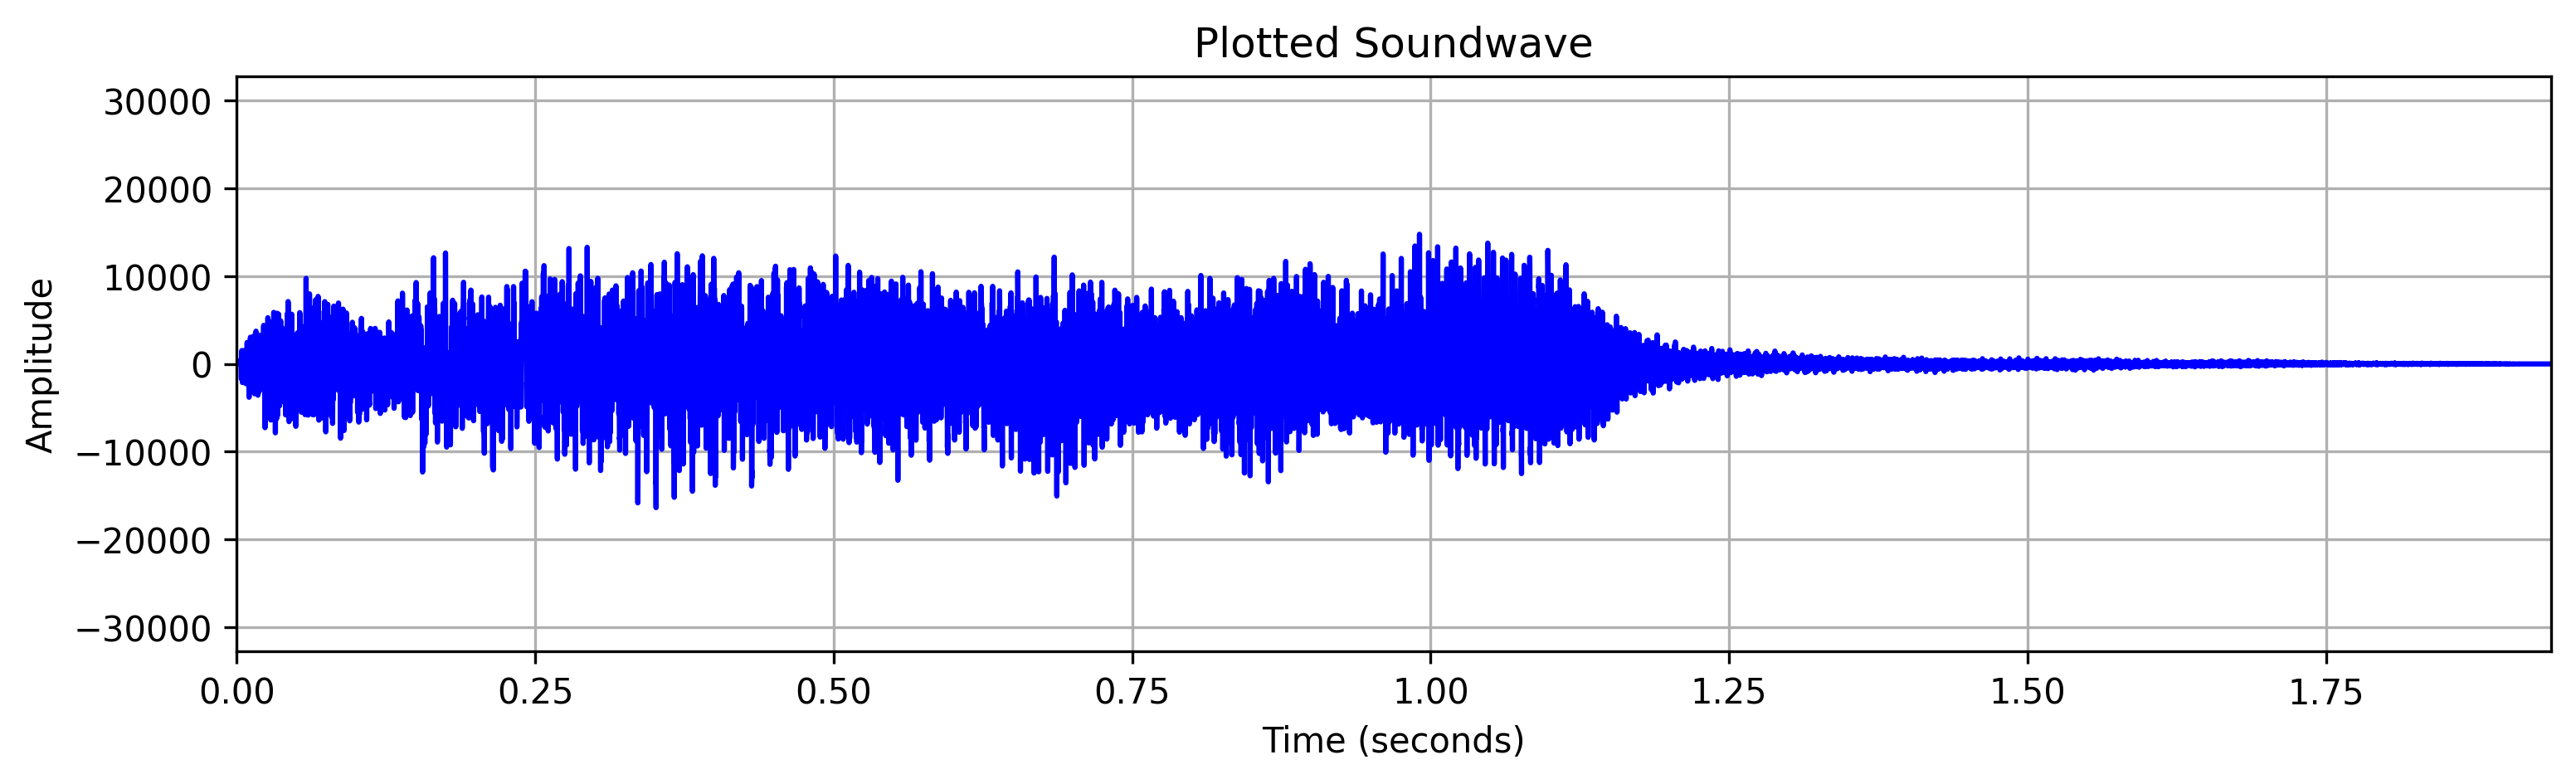

In [5]:
rate, samples = wavfile.read('tada.wav')
thing = SoundWave(rate, samples)
thing.export("unscaled.wav", force=False)
rate, samples = wavfile.read("unscaled.wav")
unscaled = SoundWave(rate, samples)
unscaled.plot()
IPython.display.Audio(filename='unscaled.wav')

## Problem 2

- Implement `SoundWave.export()`.
- Use the `export()` method to create two new files containing the same sound as `tada.wav`: one without scaling, and one with scaling (use `force=True`).
- Use `IPython.display.Audio()` to embed the original and two new versions of `tada.wav` in the cells below.

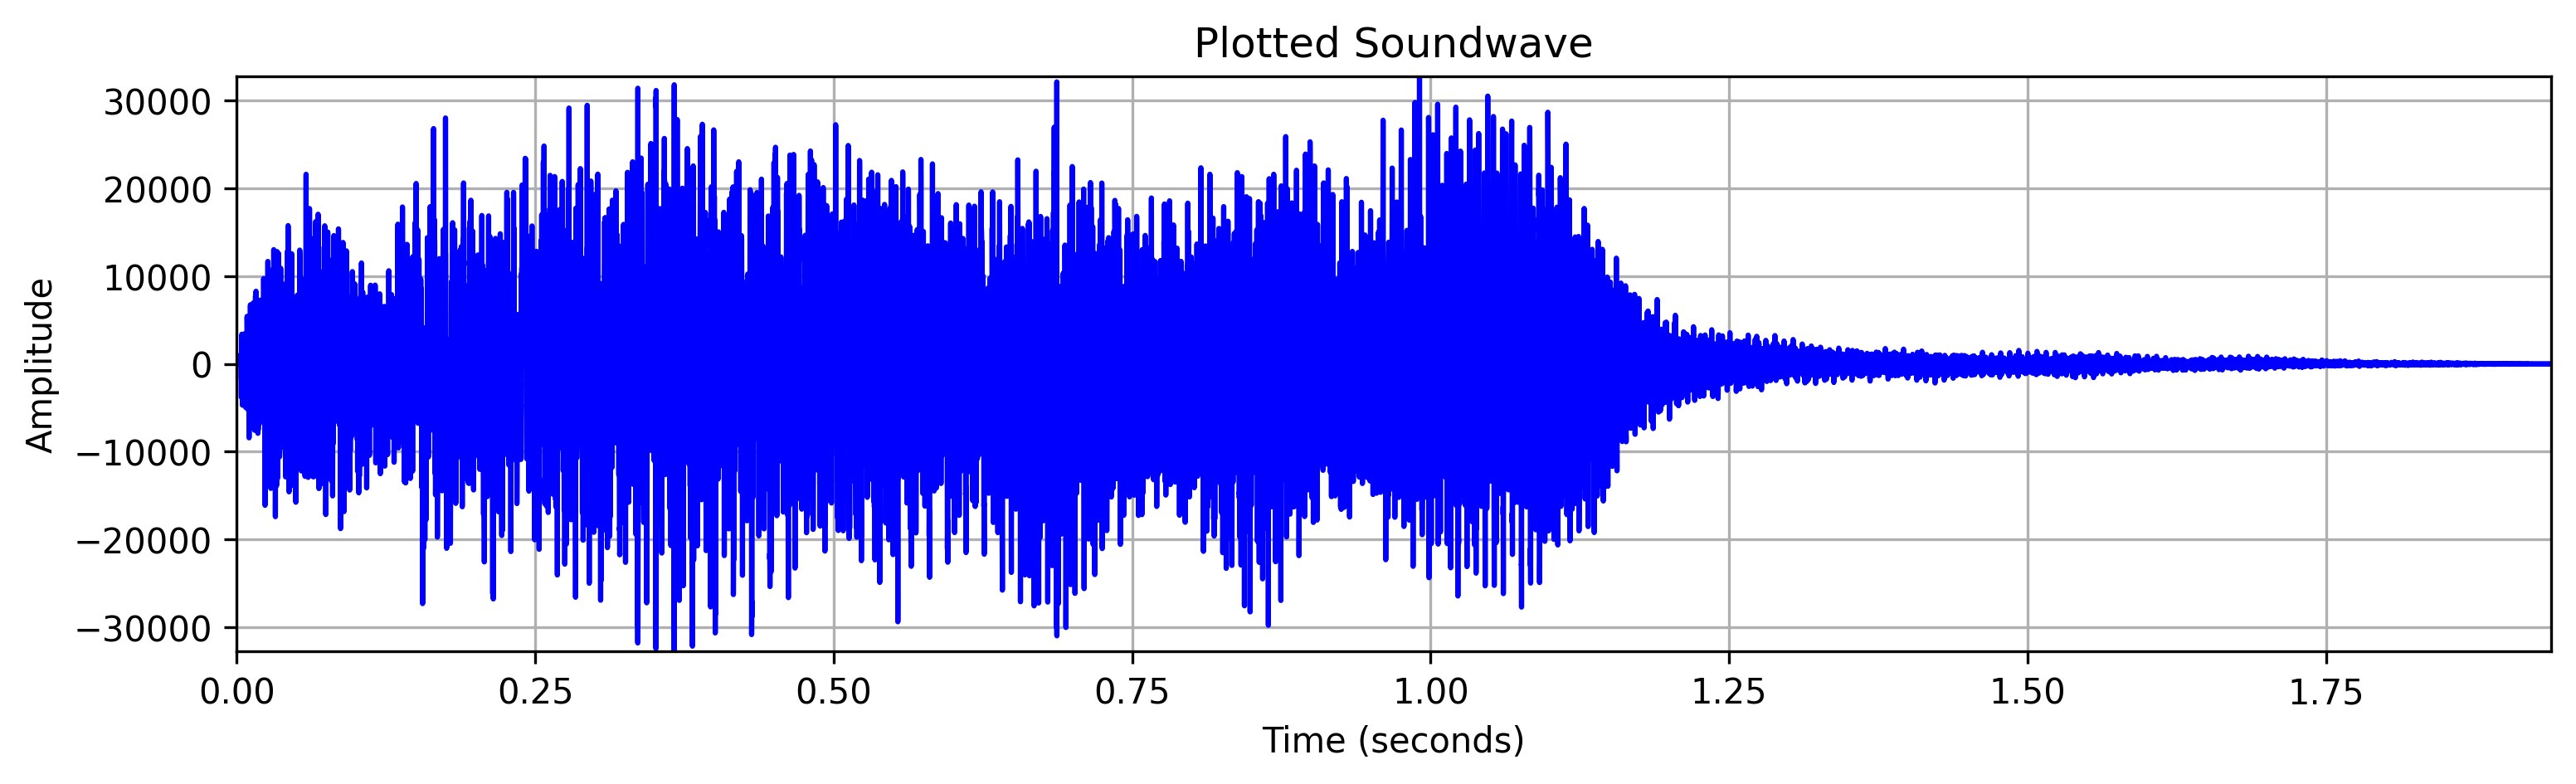

In [6]:
rate, samples = wavfile.read('tada.wav')
thing = SoundWave(rate, samples)
thing.export("scaled.wav", force=True)
thing.export("unscaled.wav", force=False)
rate, samples = wavfile.read("scaled.wav")
scaled = SoundWave(rate, samples)
scaled.plot()
rate, samples = wavfile.read("unscaled.wav")
unscaled = SoundWave(rate, samples)
unscaled.plot()
IPython.display.Audio(filename="scaled.wav")

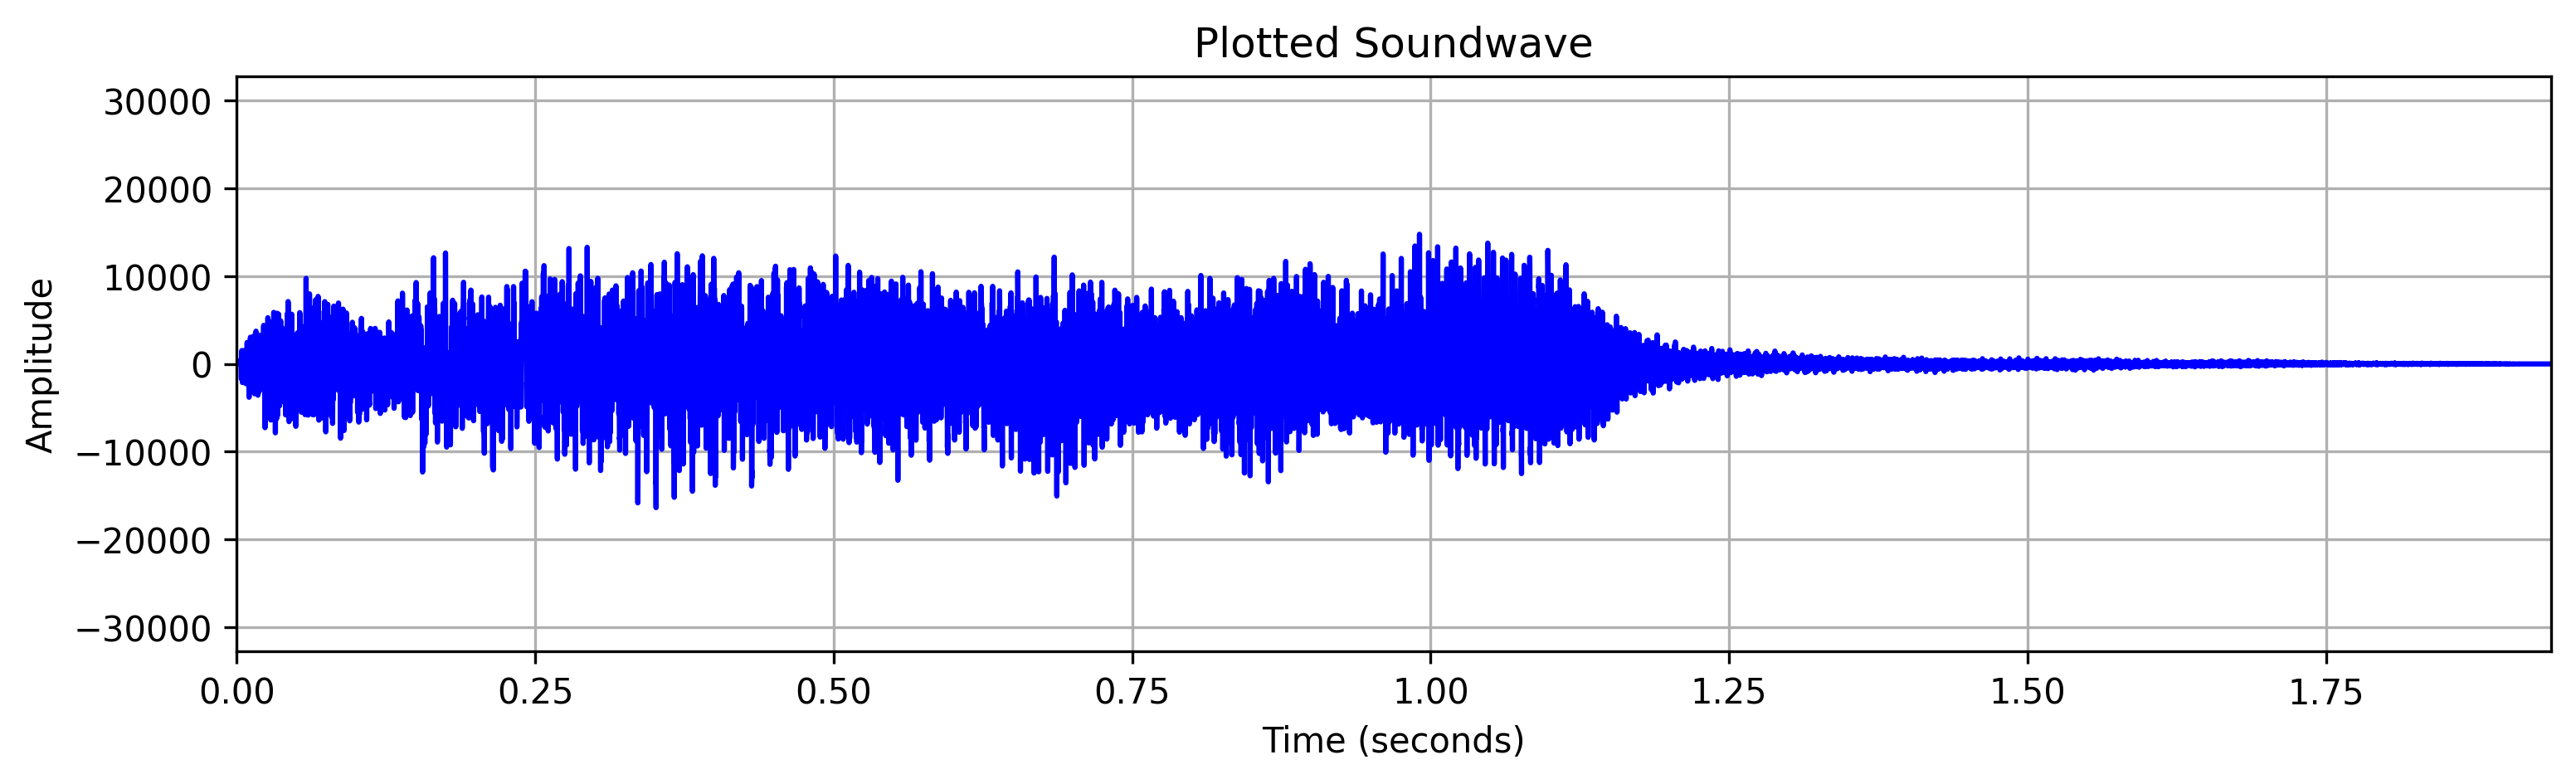

In [7]:
IPython.display.Audio(filename="unscaled.wav")
unscaled.plot()

In [8]:
IPython.display.Audio(filename='tada.wav')

## Problem 3

- Implement `generate_note()`.
- Use `generate_note()` to create an A tone that lasts for two seconds. Embed it in the cell below.

In [9]:
def generate_note(frequency, duration):
    """Generate an instance of the SoundWave class corresponding to 
    the desired soundwave. Uses sample rate of 44100 Hz.
    
    Parameters:
        frequency (float): The frequency of the desired sound.
        duration (float): The length of the desired sound in seconds.
    
    Returns:
        sound (SoundWave): An instance of the SoundWave class.
    """
    # default sample rate, which is used to compute length and returns a SoundWave
    sample_rate = 44100
    sample_count = int(sample_rate * duration)
    t = np.linspace(0, duration, sample_count, endpoint=False)
    samples = np.sin(2 * np.pi * frequency * t)
    return SoundWave(sample_rate, samples)


In [10]:
A = generate_note(440, 2)
A.export("A.wav")
IPython.display.Audio("A.wav")

## Problem 4

- Implement `SoundWave.__add__()`.
- Generate a three-second A minor chord (A, C, and E) and embed it in the first cell below.
- Implement `SoundWave.__rshift__()`.
- Generate the arpeggio A &rarr; C &rarr; E, where each tone lasts one second, and embed it in the second cell below.

In [11]:
# generate a Chord A C E
A = generate_note(440, 3)
A.export('A.wav')
C = generate_note(523.25, 3)
C.export("C.wav")
E = generate_note(659.25, 3)
E.export('E.wav')
chord = A + C + E
chord.export('chord.wav')
IPython.display.Audio("chord.wav")

In [12]:
# generate an arpeggio of A, C, E 3 seconds long total
A = generate_note(440, 1)
A.export('A.wav')
C = generate_note(523.25, 1)
C.export("C.wav")
E = generate_note(659.25, 1)
E.export('E.wav')
arpeggio = A >> C >> E
arpeggio.export('arpeggio.wav')
IPython.display.Audio("arpeggio.wav")

## Problem 5

- Implement `simple_dft()` with the formula $c=F_nf$, where $F_n$ is the n-dimensional DFT matrix.
- In the cell below, use `np.allclose()` to check that `simple_dft()` and `scipy.fftpack.fft()` give the same result (after scaling).

In [13]:
def simple_dft(samples):
    """Compute the DFT of an array of samples.

    Parameters:
        samples ((n,) ndarray): an array of samples.
    
    Returns:
        ((n,) ndarray): The DFT of the given array.
    """
    # the naive implementation of a DFT as straight matrix multiplication
    x = np.asarray(samples, dtype=np.complex128)
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(-2j * np.pi * k * n / N)
    X = (W @ x) / N
    return X

In [14]:

x = np.random.rand(8) + 1j*np.random.rand(8)

X_simple = simple_dft(x)

X_np = fft(x) / len(x)

print(np.allclose(X_simple, X_np)) # quick test

True


## Problem 6

- Implement `simple_fft()`.
- In the cell below:
    - Generate an array of $8192$ random samples and take its DFT using `simple_dft()`, `simple_fft()`, and `scipy.fftpack.fft()`.
    - Print the runtimes of each computation.
    - Use `np.allclose()` to check that `simple_fft()` and `scipy.fftpack.fft()` give the same result (after scaling).

In [15]:
def simple_fft(samples, threshold=1):
    """Compute the DFT using the FFT algorithm.
    
    Parameters:
        samples ((n,) ndarray): an array of samples.
        threshold (int): when a subarray of samples has fewer
            elements than this integer, use simple_dft() to
            compute the DFT of that subarray.
    
    Returns:
        ((n,) ndarray): The DFT of the given array.
    """
    x = np.asarray(samples, dtype=np.complex64)
    N = len(x)
    if N == 1:
        return simple_dft(x)
    
    # split as is standart in fft and recursively call
    X_even = simple_fft(x[::2], threshold)
    X_odd = simple_fft(x[1::2], threshold)
    
    k = np.arange(N//2) # only need half because we are splitting
    W = np.exp(-2j * np.pi * k / N)
    
    X = np.zeros(N, dtype=np.complex128)
    half = N // 2
    X[:half] = X_even + W * X_odd
    X[half:] = X_even - W * X_odd
    return X


In [16]:
N = 2**10
x = np.random.rand(N) + 1j*np.random.rand(N)

X_simple_dft = simple_dft(x) * N
X_simple_fft = simple_fft(x)
X_scipy_fft = fft(x)

# test if they really are close
print("DFT close to SciPy:", np.allclose(X_simple_dft, X_scipy_fft))
print("FFT close to SciPy:", np.allclose(X_simple_fft, X_scipy_fft))

%time X_simple_dft = simple_dft(x) * N
%time X_simple_fft = simple_fft(x)
%time X_scipy_fft = fft(x)


DFT close to SciPy: True
FFT close to SciPy: True
CPU times: total: 46.9 ms
Wall time: 35.4 ms
CPU times: total: 15.6 ms
Wall time: 15 ms
CPU times: total: 0 ns
Wall time: 57.5 μs


## Problem 7

- Modify `SoundWave.plot()` so that it accepts a boolean. When the boolean is `True`, take the DFT of the stored samples and plot (in a new subplot) the frequencies present on the $x$-axis and the magnituds of those frequences on the $y$-axis. Only the display the first half of the plot, and adjust the $x$-axis so that it correctly shows the frequencies in Hertz.
- Display the plot of the DFT of the A tone from Problem 4 the first cell below.
- Display the plot of the DFT of the A minor chord from Problem 4 in the second cell below.

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft

class SoundWave:
    """A class for working with digital audio signals."""

    def __init__(self, rate, samples):
        self.rate = rate
        self.samples = np.asarray(samples, dtype=np.float32)

    def plot(self, show_dft=False):
        """Plot the time-domain signal and optionally its DFT."""
        t = np.arange(len(self.samples)) / self.rate

        if show_dft:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
            # first plot the original kind of plot
            ax1.plot(t, self.samples, color='blue')
            ax1.set_xlabel("Time (seconds)")
            ax1.set_ylabel("Amplitude")
            ax1.set_title("Time-Domain Signal")
            ax1.grid(True)

            N = len(self.samples)
            X = fft(self.samples)
            freqs = np.fft.fftfreq(N, d=1/self.rate)
            # plot the fourier transform
            mask = freqs > 0
            ax2.plot(freqs[mask], np.abs(X[mask]), color='red')
            ax2.set_xlabel("Frequency (Hz)")
            ax2.set_ylabel("Magnitude")
            ax2.set_title("Frequency-Domain (DFT) Magnitude")
            ax2.grid(True)

            plt.tight_layout()
            plt.show()
        else:
            plt.figure(figsize=(10, 3))
            plt.plot(t, self.samples, color='blue')
            plt.xlabel("Time (seconds)")
            plt.ylabel("Amplitude")
            plt.grid(True)
            plt.show()
    def export(self, filename, force=False):
        """Generate a wav file from the sample rate and samples. 
        If the array of samples is not of type np.int16, scale it before exporting.

        Parameters:
            filename (str): The name of the wav file to export the sound to.
        """
        scaled_samples = self.samples
        if (self.samples.dtype != np.int16) or force:
            scaled_samples = ((self.samples/max(self.samples)) * 32767).astype(np.int16)

        wavfile.write(filename, self.rate, scaled_samples)
    def __add__(self, other):
        """Combine the samples from two SoundWave objects.

        Parameters:
            other (SoundWave): An object containing the samples to add
                to the samples contained in this object.
        
        Returns:
            (SoundWave): A new SoundWave instance with the combined samples.

        Raises:
            ValueError: if the two sample arrays are not the same length.
        """
        if isinstance(other, SoundWave):
            if len(self.samples) != len(other.samples):
                raise ValueError
            return SoundWave(self.rate, self.samples + other.samples)

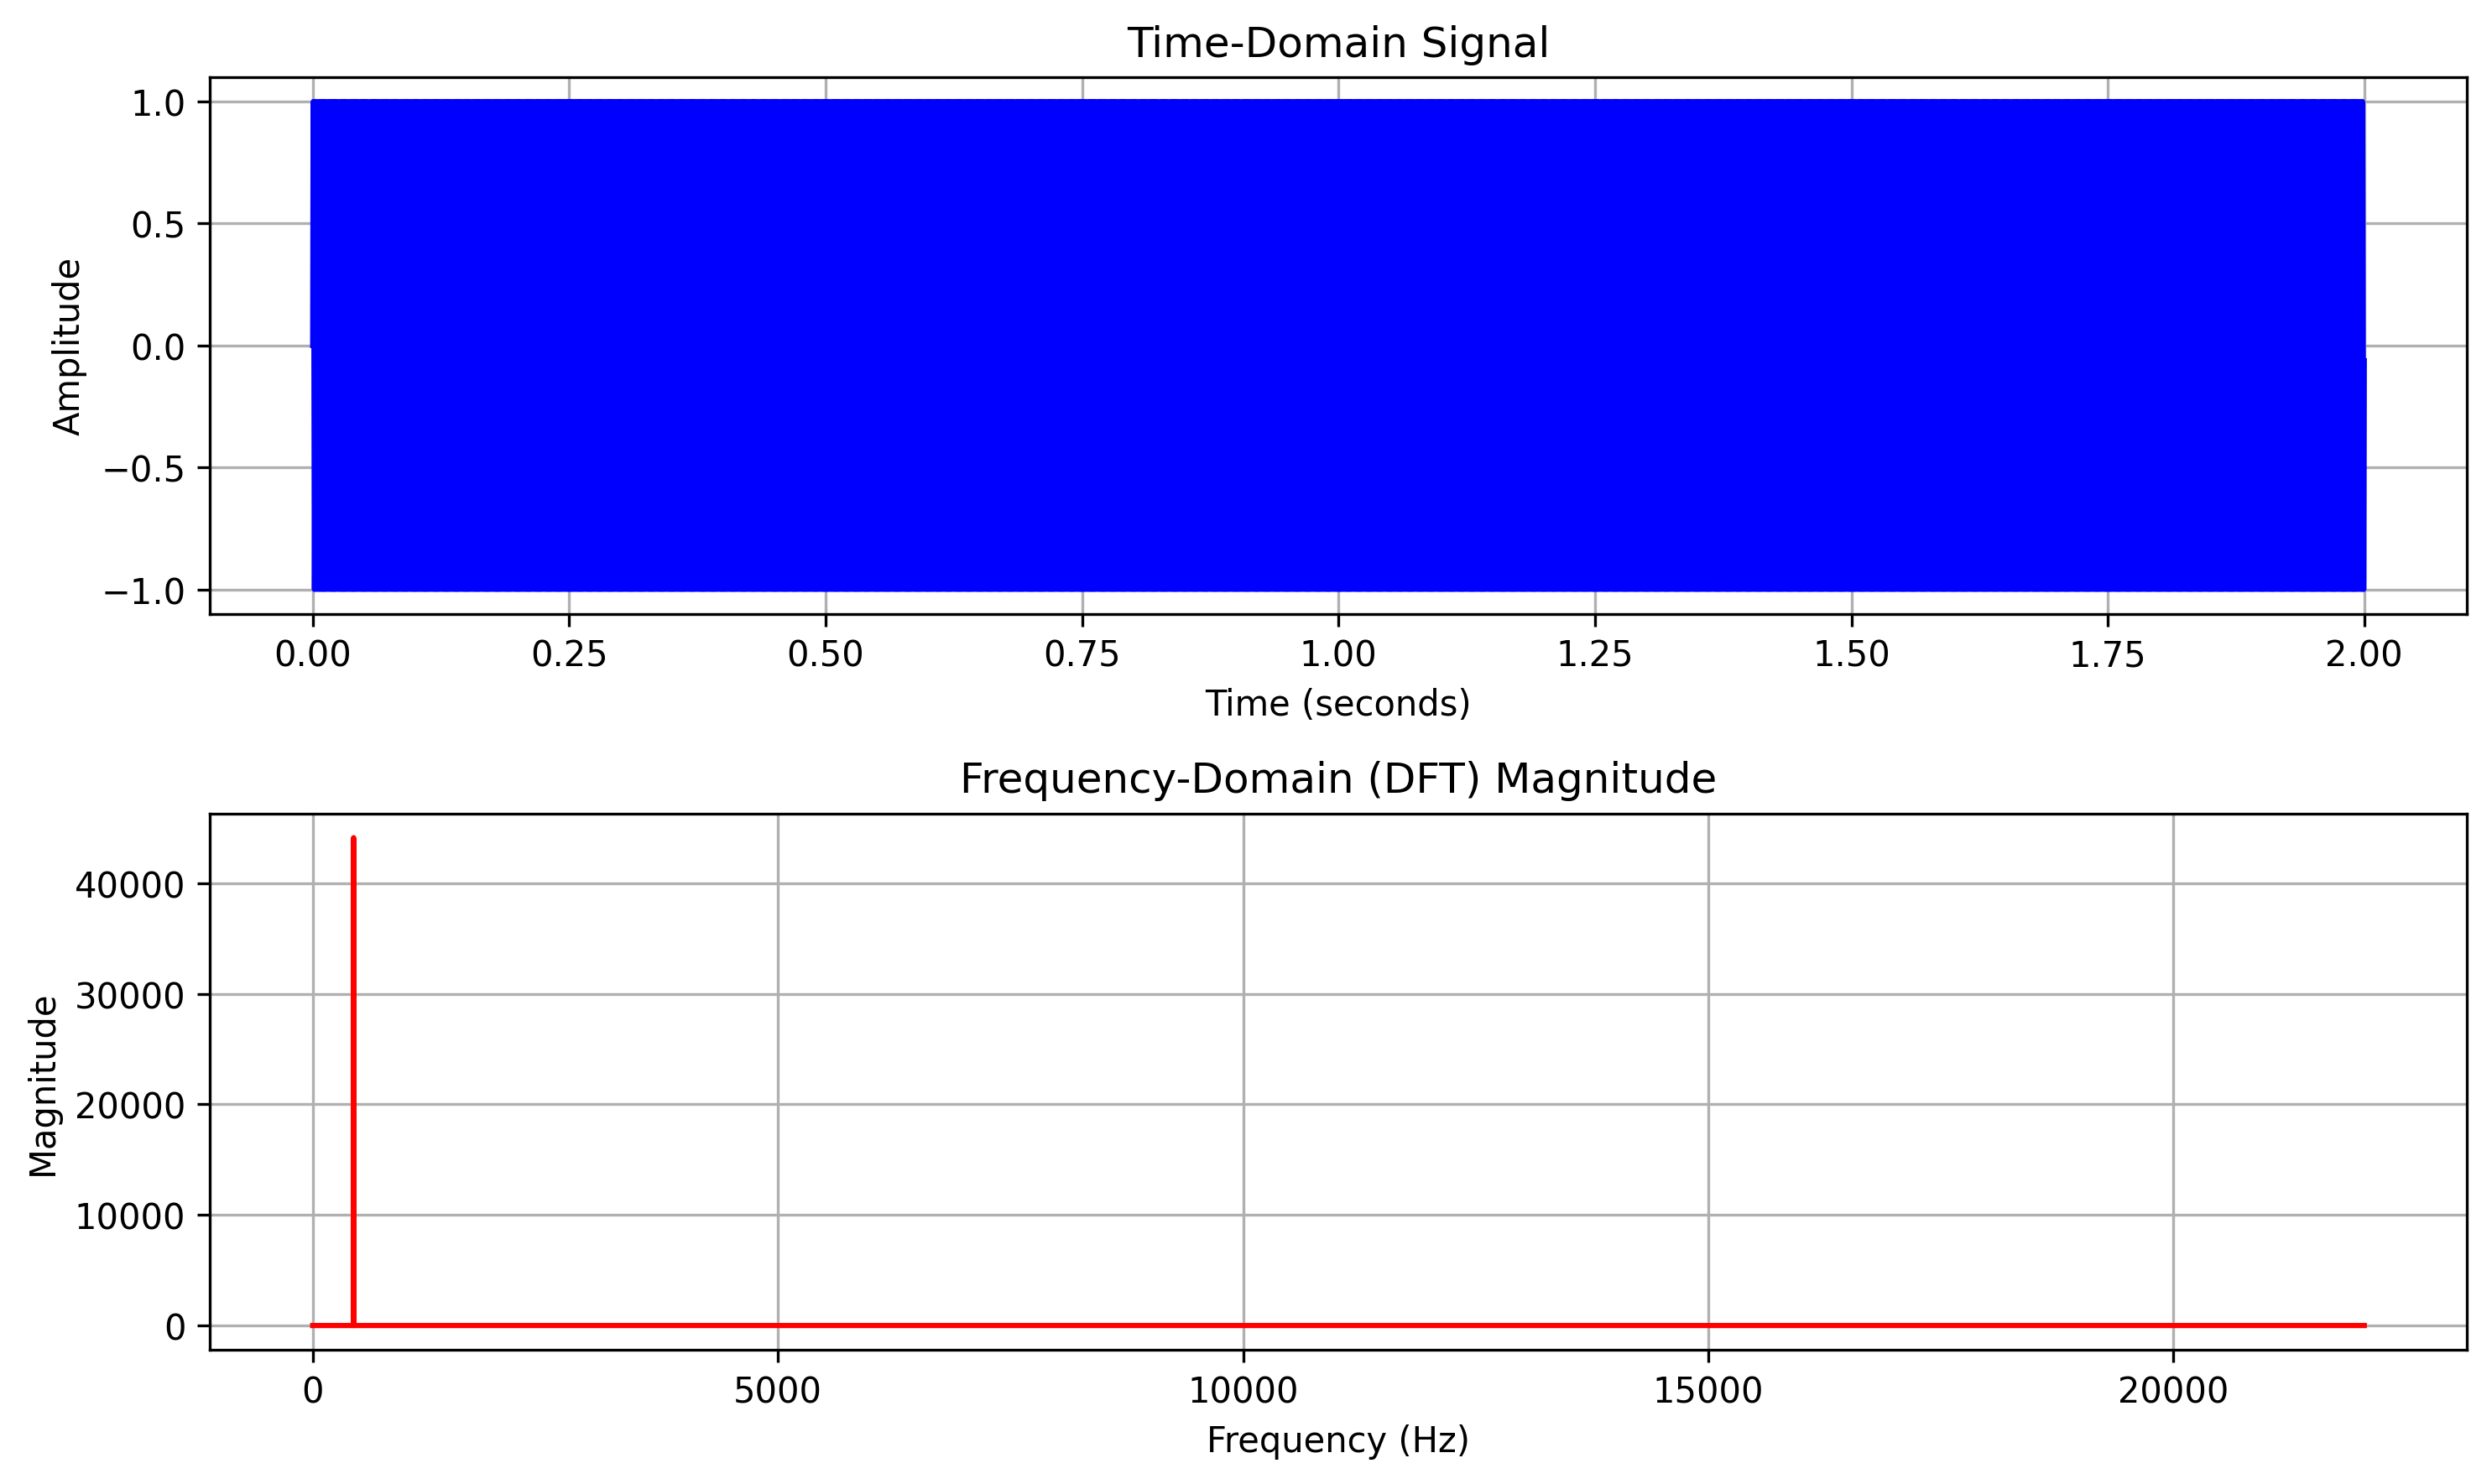

In [18]:
A = generate_note(440, 2)
A.export('A.wav')
A.plot(show_dft=True)

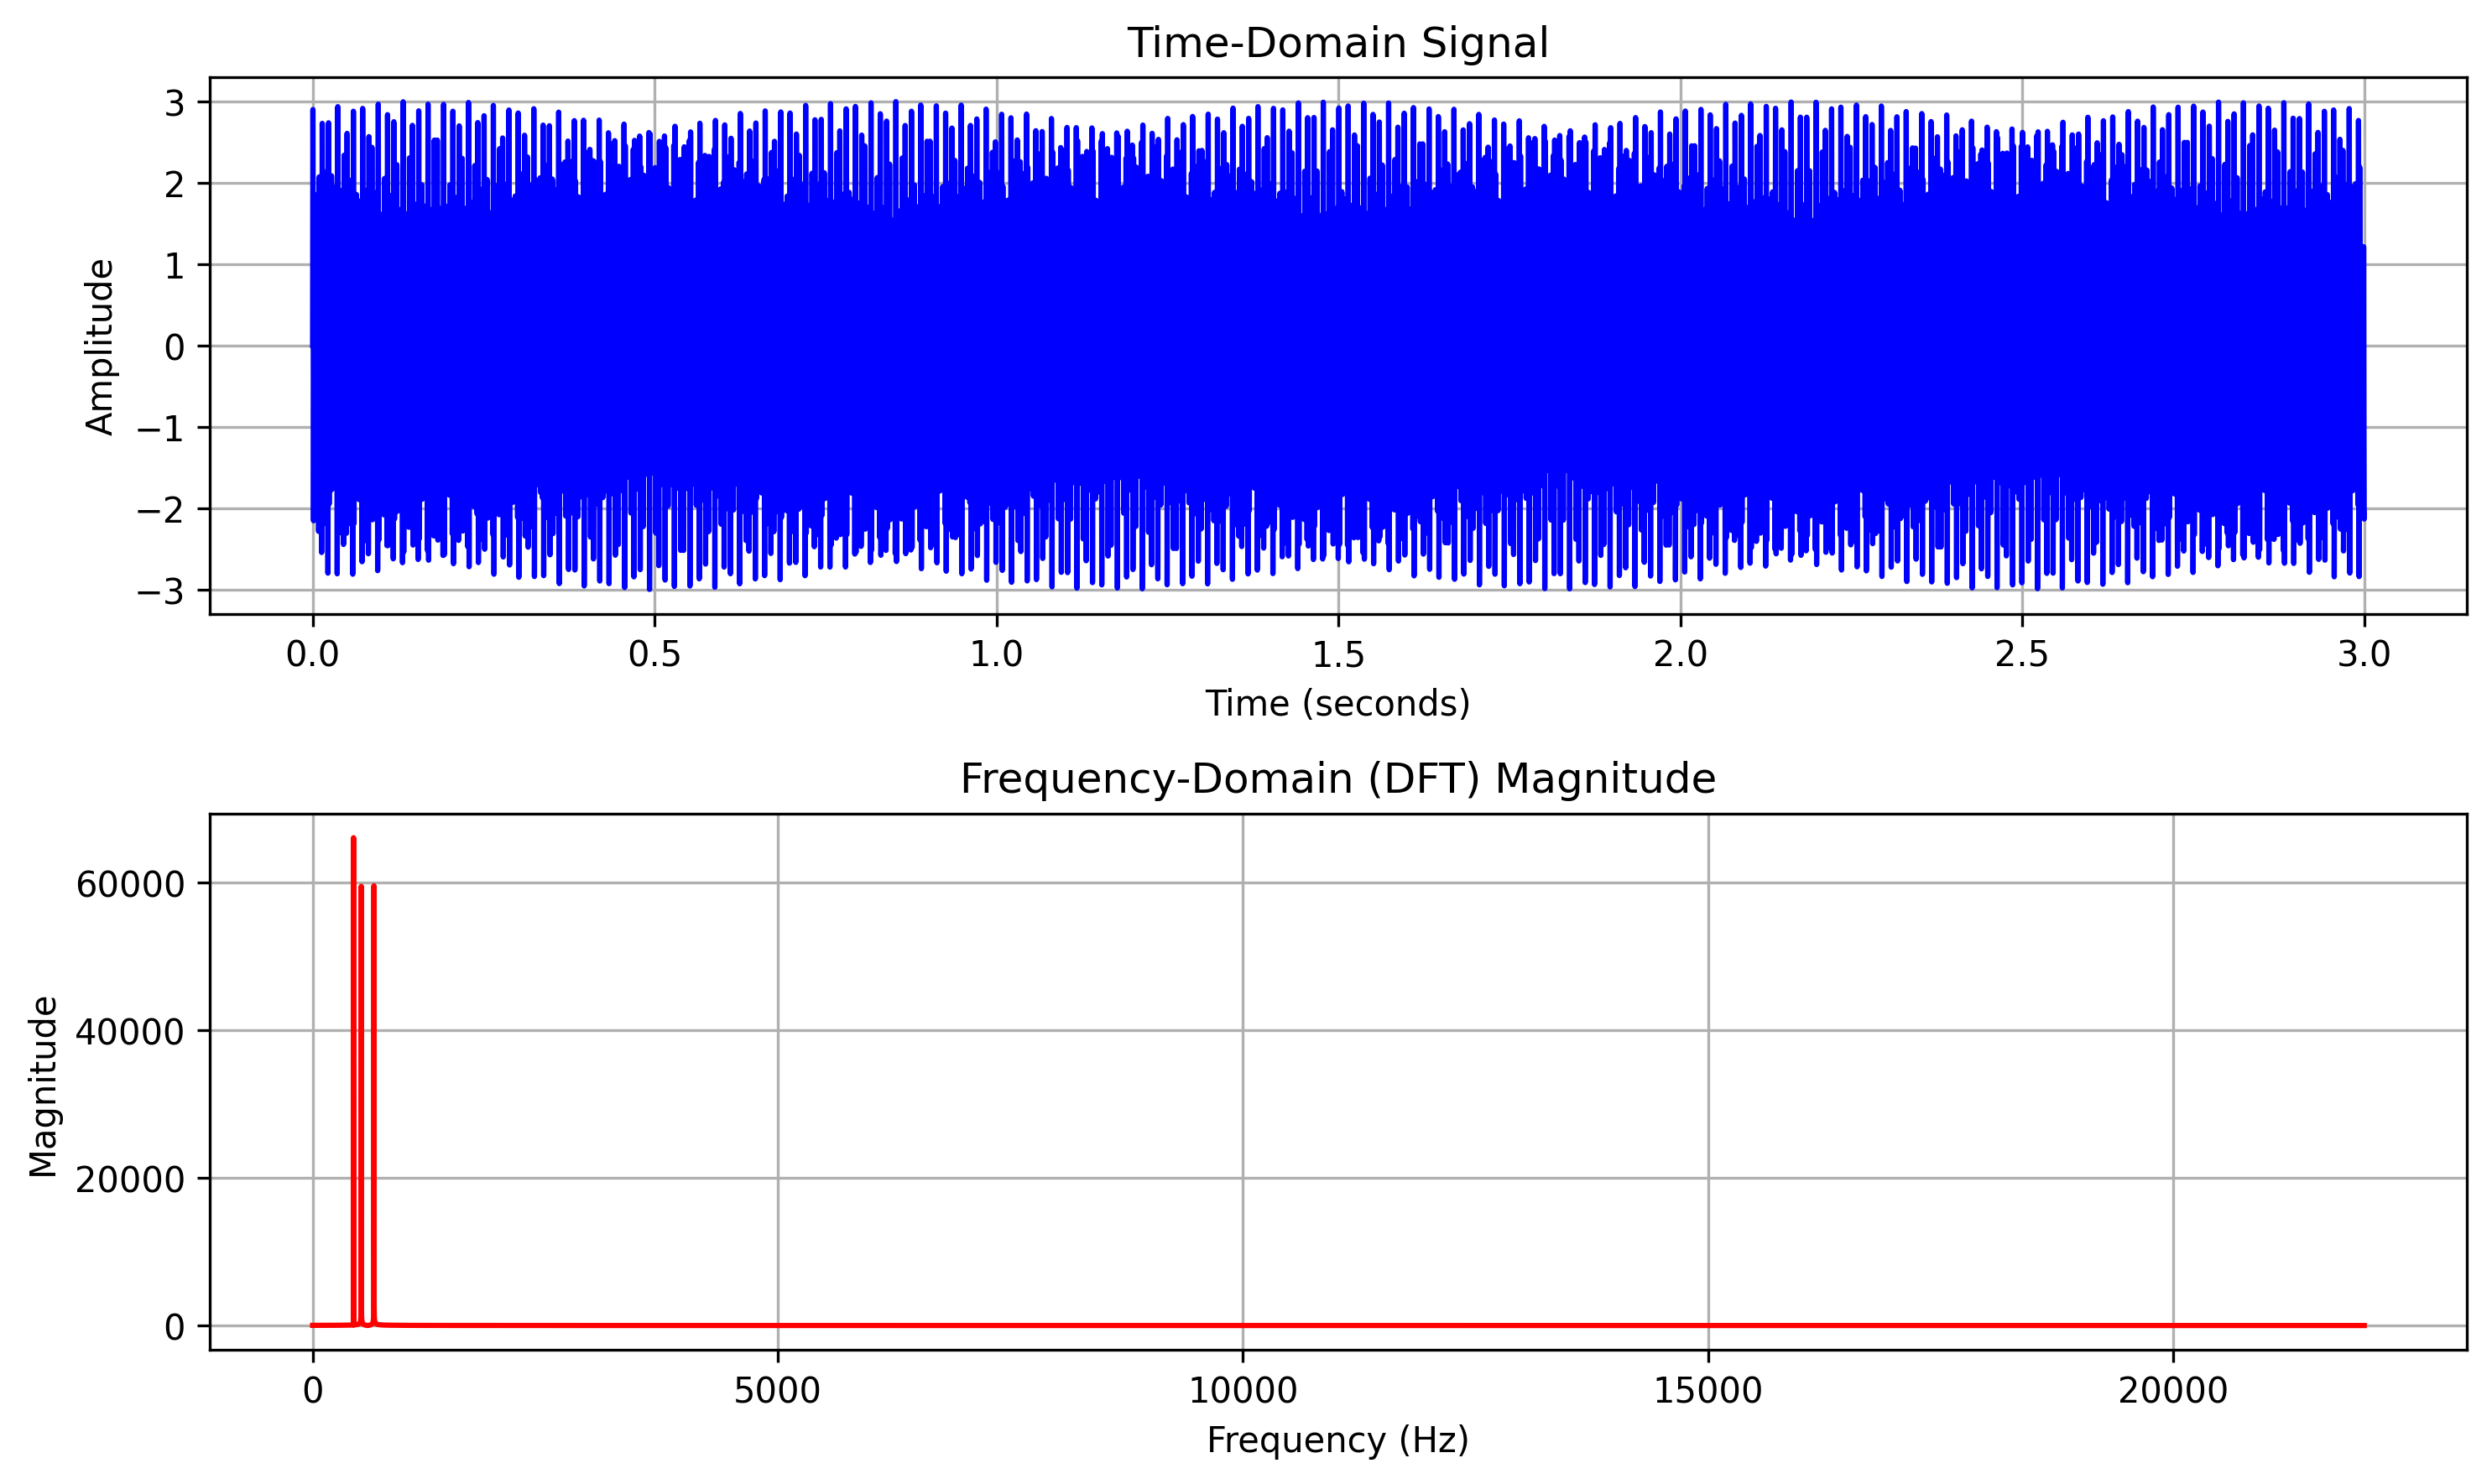

In [19]:
# build the chord starting with A then C then E
A = generate_note(440, 3)
A.export('A.wav')
C = generate_note(523.25, 3)
C.export("C.wav")
E = generate_note(659.25, 3)
E.export('E.wav')
chord = A + C + E
chord.plot(show_dft=True)

## Problem 8

Use the DFT to determine the individual notes that are present in `mystery_chord.wav`.

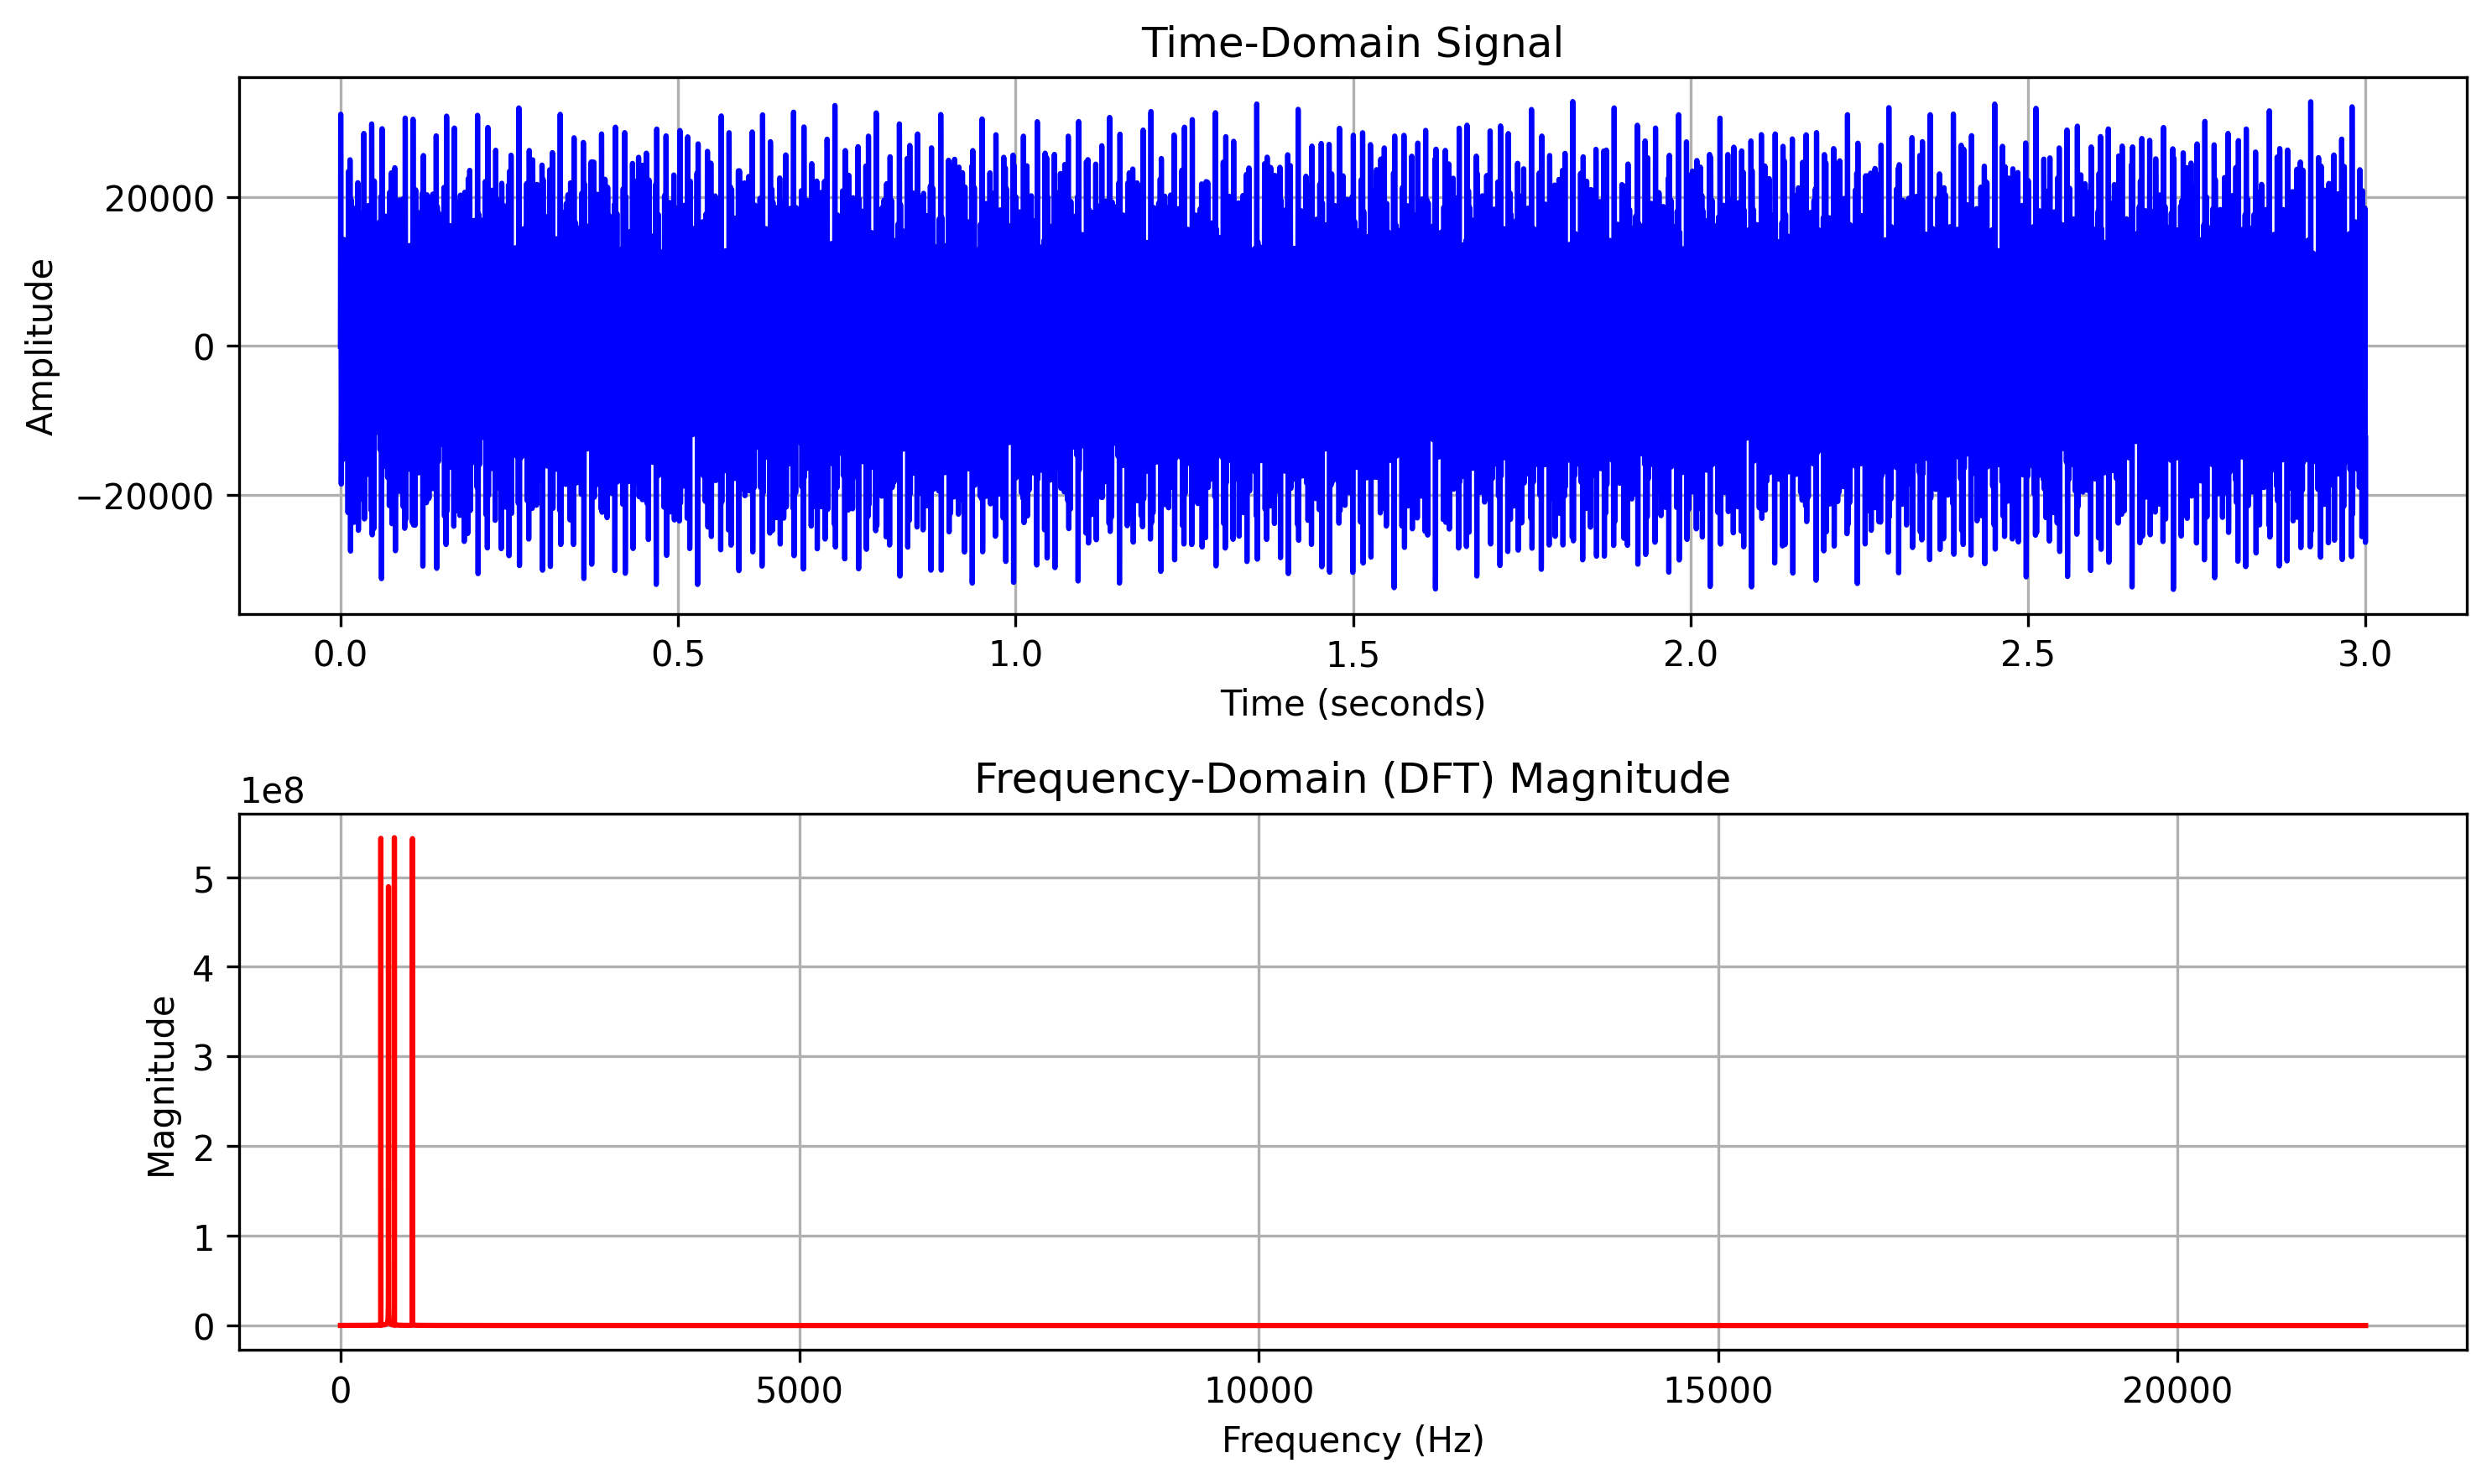

Top frequencies (Hz): [587.33333333 440.         784.         523.33333333]
Notes in the chord: ['D', 'A', 'G', 'C']


In [20]:
rate, samples = wavfile.read("mystery_chord.wav")
mystery = SoundWave(rate, samples)
mystery.plot(show_dft=True)

N = len(samples)
X = fft(samples)

X_half = X[:N//2]
freqs = np.fft.fftfreq(N, d=1/rate)[:N//2]
magnitudes = np.abs(X_half)
top_indices = np.argsort(magnitudes)[-4:][::-1]

top_freqs = freqs[top_indices]
print("Top frequencies (Hz):", top_freqs)

note_freqs = {
    "A": 440.00,
    "B": 493.88,
    "C": 523.25,
    "D": 587.33,
    "E": 659.25,
    "F": 698.46,
    "G": 783.99,
}

def freq_to_note(f):
    # finds closest note by minimizing the difference
    closest_note = min(note_freqs, key=lambda n: abs(note_freqs[n]-f))
    return closest_note

notes_in_chord = [freq_to_note(f) for f in top_freqs]
print("Notes in the chord:", notes_in_chord)
IPython.display.Audio("mystery_chord.wav")

